## Decode self-prediciton

Self predict the 3D calibration set.  For an isolated bead we should get linear z positions as a function of image, since the images represent a stack (not a series)

In [1]:
import sys

import decode
import decode.utils

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import yaml
import os
from wip_util import zero_pad_index
from skimage.io import imread

print(f"DECODE version: {decode.utils.bookkeeping.decode_state()}")

# set device and num threads
device = 'cuda:0'  # or 'cpu', or you change cuda device index
threads = 3  #  number of threads, useful for CPU heavy computation. Change if you know what you are doing.
worker = 0  # number of workers for data loading. Used a default of 0 for safety. Multiprocessing on windows is sometimes not stable

torch.set_num_threads(threads)  # set num threads

if device != 'cpu':
    if not torch.cuda.is_available():
        raise ValueError("You have selected a non CPU device, but CUDA is not available."
                         "Refer to CPU version or check your installation.")

c:\Users\bnort\miniconda3\envs\decode_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DECODE version: v0.10.2-4-gcf6ba01-dirty


In [2]:
frame_path = r'D:\Janelia_slm_data\calibrations\Janelia PALM RUN2\1a - Astigmatic_Widefield_scaffold_Z-Stack_RAW_TIFF_IMAGE.tif'
#frame_path = r'D:\Janelia_slm_data\calibrations\Janelia PALM RUN2\crops\cropped_0.tif'
out_path = r'D:\Janelia_slm_data\calibrations\Janelia PALM RUN2\selfprediction'
fig_path = os.path.join(out_path, 'figures')

if not os.path.exists(out_path):
    os.makedirs(out_path)

if not os.path.exists(fig_path):
    os.makedirs(fig_path)

model_path = r'D:\Janelia_slm_data\models\Janelia PALM RUN2\2025-06-25-calibration\decode_model_0.pt'
param_path = r'D:\Janelia_slm_data\models\Janelia PALM RUN2\2025-06-25-calibration\params.yaml'
#model_path = r'D:\Janelia_slm_data\models\Janelia PALM RUN2\2025-06-25\decode_model_0.pt'
#param_path = r'D:\Janelia_slm_data\models\Janelia PALM RUN2\2025-06-25\params.yaml'
model_name = 'Janelia PALM RUN2_2025-06-25'

## Load parameters and model

In [3]:
param = decode.utils.param_io.load_params(param_path)
model = decode.neuralfitter.models.SigmaMUNet.parse(param)
model = decode.utils.model_io.LoadSaveModel(model,
                                            input_file=model_path,
                                            output_file=None).load_init(device=device)
camera = decode.simulation.camera.Photon2Camera.parse(param)
camera.device = 'cpu'

Model instantiated.
Model SHA-1 hash: f58968c059bbf504ce2d6578361310e9e9f8f650
Loaded pretrained model: D:\Janelia_slm_data\models\Janelia PALM RUN2\2025-06-25-calibration\decode_model_0.pt


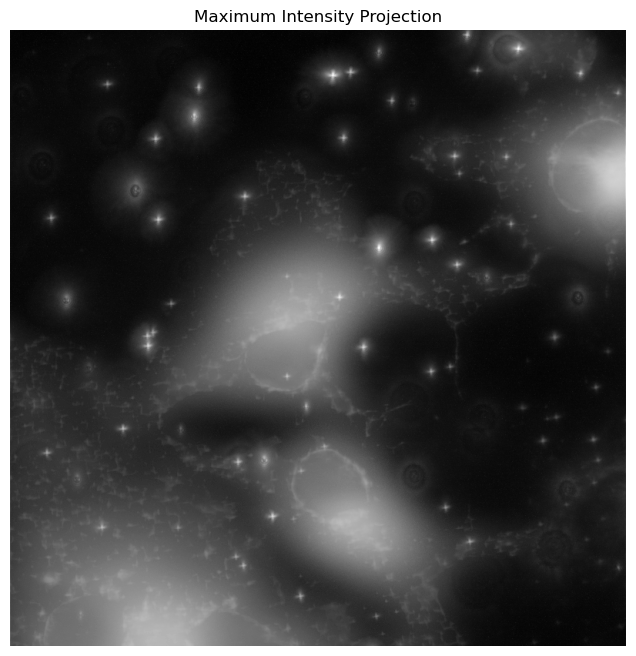

In [4]:
frames = imread(frame_path)
# Compute maximum intensity projection (MIP)
max_projection = np.log1p(np.max(frames, axis=0))  # Collapse along depth
# Display the MIP using matplotlib
plt.figure(figsize=(8, 8))
plt.imshow(max_projection, cmap='gray')
plt.axis("off")
plt.title("Maximum Intensity Projection")
plt.show()


## Setup frames preprocessing

In [5]:
frames_ = torch.tensor(frames[:10].astype('float32'), dtype=torch.float32, device=device)

# setup frame processing as by the parameter with which the model was trained
frame_proc = decode.neuralfitter.utils.processing.TransformSequence([
    decode.neuralfitter.utils.processing.wrap_callable(camera.backward),
    decode.neuralfitter.frame_processing.AutoCenterCrop(8),
    #decode.neuralfitter.frame_processing.Mirror2D(dims=-1),  # WARNING: You might need to comment this line out. see above
    decode.neuralfitter.scale_transform.AmplitudeRescale.parse(param)
])

# determine extent of frame and its dimension after frame_processing
size_procced = decode.neuralfitter.frame_processing.get_frame_extent(frames_.unsqueeze(1).size(), frame_proc.forward)  # frame size after processing
frame_extent = ((-0.5, size_procced[-2] - 0.5), (-0.5, size_procced[-1] - 0.5))


# Setup post-processing
# It's a sequence of backscaling, relative to abs. coord conversion and frame2emitter conversion
post_proc = decode.neuralfitter.utils.processing.TransformSequence([

    decode.neuralfitter.scale_transform.InverseParamListRescale.parse(param),

    decode.neuralfitter.coord_transform.Offset2Coordinate(xextent=frame_extent[0],
                                                          yextent=frame_extent[1],
                                                          img_shape=size_procced[-2:]),

    decode.neuralfitter.post_processing.SpatialIntegration(raw_th=0.1,
                                                          xy_unit='px',
                                                          px_size=param.Camera.px_size)


])

c:\Users\bnort\miniconda3\envs\decode_env\lib\site-packages\torch\functional.py:478: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at  C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\TensorShape.cpp:2895.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [6]:
infer = decode.neuralfitter.Infer(model=model, ch_in=param.HyperParameter.channels_in,
                                  frame_proc=frame_proc, post_proc=post_proc,
                                  device=device, num_workers=worker)

infer.batch_size = 8 

In [7]:
frames = torch.tensor(frames.astype('float32'), dtype=torch.float32, device=device) 
print(f"Frames shape: {frames.shape}")
emitter = infer.forward(frames)

print(emitter)
    

Frames shape: torch.Size([601, 800, 800])


100%|██████████| 76/76 [01:30<00:00,  1.20s/it]


EmitterSet
::num emitters: 720755
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 0 - 600
::spanned volume: [ 8.3724618e-02 -8.3444393e-01 -1.3649014e+03] - [ 799.8646   799.18286 1440.     ]


In [62]:
sigma_x_high_threshold = 20
sigma_y_high_threshold = 20
sigma_z_high_threshold = 50
prob_threshold = 0.8

print(emitter)

emitters_filtered = emitter[
    (emitter.xyz_sig_nm[:, 0] <= sigma_x_high_threshold)
    * (emitter.xyz_sig_nm[:, 1] <= sigma_x_high_threshold)
    * (emitter.xyz_sig_nm[:, 2] <= sigma_z_high_threshold)
    * (emitter.prob >= prob_threshold)
    ]

print(emitters_filtered)

EmitterSet
::num emitters: 720755
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 0 - 600
::spanned volume: [ 8.3724618e-02 -8.3444393e-01 -1.3649014e+03] - [ 799.8646   799.18286 1440.     ]
EmitterSet
::num emitters: 10726
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 0 - 600
::spanned volume: [ 1.3753057e+00 -4.6120667e-01 -1.3101388e+03] - [ 784.04297  790.3166  1347.2701 ]


In [9]:
import napari
viewer = napari.Viewer()
viewer.add_image(frames.cpu().numpy(), name='Frames', colormap='gray')

<Image layer 'Frames' at 0x21c9bea56d0>

In [10]:
#from wip_util import reverse_emitters
#reverse_emitters(emitters_filtered, frames.shape[:2], 1, 1)

In [11]:
from wip_util import get_np_points
points = get_np_points(emitters_filtered, 0, 600, True)
print(points.shape)
#points = points[points[:,0] == points[0,0]]
print(points.shape)
points_ = points[:, 0:3]
viewer.add_points(points_, name='Emitters', size=5, face_color='red')

(18328, 4)
(18328, 4)


<Points layer 'Emitters' at 0x216fdb84f10>

In [12]:
viewer2 = napari.Viewer()
frames_cropped = frames[:, 110:170, 160:220]
viewer2.add_image(frames_cropped.cpu().numpy(), name='Frames')

<Image layer 'Frames' at 0x21d02951fd0>

In [13]:
bead = emitters_filtered[
    (emitters_filtered.xyz_px[:, 1]>= 160) & (emitters_filtered.xyz_px[:, 1] <= 220) &
    (emitters_filtered.xyz_px[:, 0]>= 110) & (emitters_filtered.xyz_px[:, 0] <= 170) 
    #(emitters_filtered.frame_ix==29)
]

print(bead.xyz_px[0])


bead_points = get_np_points(bead, 0, 600, True)
print(bead_points[0])

bead_points_ = bead_points[:, 0:3]
bead_points_[:, 1] -= 110  # Adjust x-coordinates to match cropped image
bead_points_[:, 2] -= 160  # Adjust y-coordinates to match cropped image
print(bead_points_[0])
viewer2.add_points(bead_points_, name='Bead Emitters', size=2, face_color='red')

print(bead_points)


tensor([ 140.8349,  189.1569, 1326.6821])
[  96.          140.83491516  189.15690613 1326.68212891]
[96.         30.83491516 29.15690613]
[[   96.            30.83491516    29.15690613  1326.68212891]
 [   97.            30.82627869    29.08547974  1318.67431641]
 [   98.            30.86601257    29.04360962  1321.1295166 ]
 ...
 [  578.            31.82710266    28.9712677   -907.55084229]
 [  580.            31.96600342    28.98519897  -973.25817871]
 [  595.            31.49195862    29.0614624  -1106.6607666 ]]


In [14]:
def get_bead_points(emitters, xc, yc, window_size, nframes):
    """
    Extracts bead points from emitters based on a specified center and window size.
    
    Parameters:
    - emitters: Emitter data containing coordinates and other properties.
    - xc: x-coordinate of the center.
    - yc: y-coordinate of the center.
    - window_size: Size of the window to extract around the center.
    
    Returns:
    - bead_points: Points within the specified window around the center.
    """
    emitter = emitters[(
        (emitters.xyz_px[:, 1] >= xc-window_size) & (emitters.xyz_px[:, 1] < xc + window_size) &
        (emitters.xyz_px[:, 0] >= yc-window_size) & (emitters.xyz_px[:, 0] < yc + window_size)
    )]

    bead_points = get_np_points(emitter, 0, nframes, True)

    bead_points_ = bead_points[:, 0:3]
    bead_points_[:, 2] -= xc-window_size  # Adjust x-coordinates to match cropped
    bead_points_[:, 1] -= yc-window_size  # Adjust y-coordinates to match cropped image

    return bead_points, bead_points_

In [15]:
print(bead_points[210:330])

[[  309.            31.12385559    28.68009949  -646.15930176]
 [  310.            31.12281799    28.67320251  -656.97857666]
 [  312.            31.13186646    28.68099976  -676.47344971]
 [  313.            31.12600708    28.7043457   -689.46520996]
 [  314.            31.12980652    28.70465088  -696.87542725]
 [  315.            31.11180115    28.71105957  -707.18292236]
 [  316.            31.104599      28.71507263  -714.65722656]
 [  317.            31.12640381    28.71302795  -724.43554688]
 [  318.            31.12033081    28.70701599  -729.52258301]
 [  319.            31.11830139    28.679245    -737.94177246]
 [  321.            31.13398743    28.65563965  -762.21331787]
 [  322.            31.1268158     28.67297363  -773.82830811]
 [  323.            31.1317749     28.68458557  -784.12902832]
 [  324.            31.15325928    28.67520142  -794.97467041]
 [  325.            31.15600586    28.68132019  -803.85760498]
 [  326.            31.14640808    28.70307922  -812.36

In [12]:
viewer.add_points(points_, name='Emitters', size=5, face_color='red')

<Points layer 'Emitters [1]' at 0x2bf097da580>

In [17]:
from wip_util import smap_csv_to_emitters
smap_input_file = r'D:\Janelia_slm_data\calibrations\Janelia PALM RUN2\selfprediction\SMAP_full.csv'
smap_emitters = smap_csv_to_emitters(smap_input_file, 100, True)
print(smap_emitters)
smap_points = get_np_points(smap_emitters, 0, 400)
#viewer.add_points(smap_points, name = 'smap points', face_color='cyan', size=2)

EmitterSet
::num emitters: 247018
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 0 - 600
::spanned volume: [ 3.258679e+00  1.594135e+00 -1.970000e+03] - [ 806.1168  810.6002 2000.    ]
EmitterSet
::num emitters: 247018
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 0 - 600
::spanned volume: [ 3.258679e+00  1.594135e+00 -1.970000e+03] - [ 806.1168  810.6002 2000.    ]


In [72]:
sigma_x_high_threshold, sigma_y_high_threshold, sigma_z_high_threshold = 7, 7, 25

In [73]:
print(smap_emitters)

smap_emitters_filtered = smap_emitters[
    (smap_emitters.xyz_sig_nm[:, 0] <= sigma_x_high_threshold)
    * (smap_emitters.xyz_sig_nm[:, 1] <= sigma_x_high_threshold)
    * (smap_emitters.xyz_sig_nm[:, 2] <= sigma_z_high_threshold)
    * (smap_emitters.prob >= prob_threshold)
    ]

print(smap_emitters_filtered)

EmitterSet
::num emitters: 247018
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 0 - 600
::spanned volume: [ 3.258679e+00  1.594135e+00 -1.970000e+03] - [ 806.1168  810.6002 2000.    ]
EmitterSet
::num emitters: 22189
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 0 - 600
::spanned volume: [    5.578719    42.19191  -1970.      ] - [ 797.7321  797.4099 1995.352 ]


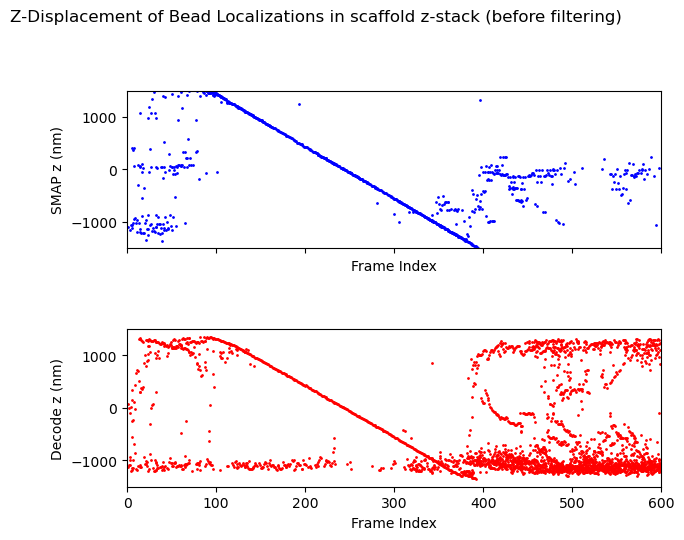

In [87]:
smap_points, smap_points_ = get_bead_points(smap_emitters, 190, 140, 30, 600)
bead_points, bead_points_ = get_bead_points(emitter, 190, 140, 30, 600)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8, 6))

# Top plot: smap_points
ax1.scatter(smap_points[:, 0], smap_points[:, 3], s=1, color='blue')
ax1.set_xlabel('Frame Index')
ax1.set_ylabel('SMAP z (nm)')
ax1.set_xlim(0, 600)
ax1.set_ylim(-1500, 1500)

# Bottom plot: bead_points
ax2.scatter(bead_points[:, 0], bead_points[:, 3], s=1, color='red')
ax2.set_xlabel('Frame Index')
ax2.set_ylabel('Decode z (nm)')
ax2.set_xlim(0, 600)
ax2.set_ylim(-1500, 1500)

fig.suptitle('Z-Displacement of Bead Localizations in scaffold z-stack (before filtering)')

fig.savefig(os.path.join(fig_path, 'bead_z_displacement_before_filtering.png'), dpi=300)

plt.tight_layout()
plt.show()



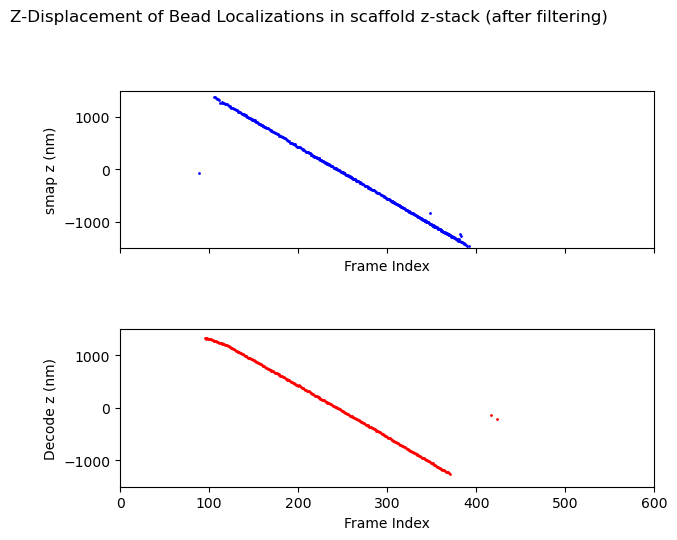

In [88]:
smap_points, smap_points_ = get_bead_points(smap_emitters_filtered, 190, 140, 30, 600)
bead_points, bead_points_ = get_bead_points(emitters_filtered, 190, 140, 30, 600)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8, 6))

# Top plot: smap_points
ax1.scatter(smap_points[:, 0], smap_points[:, 3], s=1, color='blue')
ax1.set_ylabel('smap z (nm)')
ax1.set_xlabel('Frame Index')
ax1.set_xlim(0, 600)
ax1.set_ylim(-1500, 1500)

# Bottom plot: bead_points
ax2.scatter(bead_points[:, 0], bead_points[:, 3], s=1, color='red')
ax2.set_ylabel('Decode z (nm)')
ax2.set_xlabel('Frame Index')
ax2.set_xlim(0, 600)
ax2.set_ylim(-1500, 1500)

fig.suptitle('Z-Displacement of Bead Localizations in scaffold z-stack (after filtering)')

fig.savefig(os.path.join(fig_path, 'bead_z_displacement_after_filtering.png'), dpi=300)

plt.tight_layout()
plt.show()

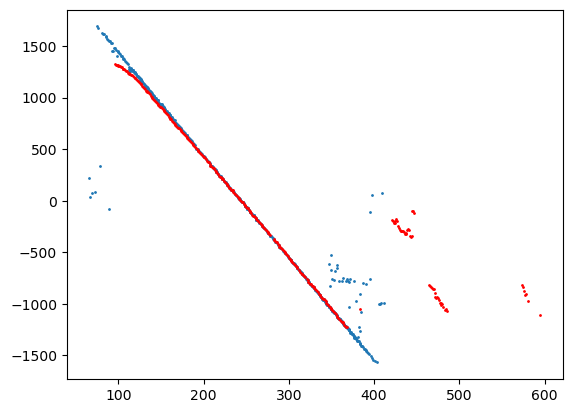

In [33]:
plt.scatter(smap_points[:, 0], smap_points[:, 3], s=1)
plt.scatter(bead_points[:, 0], bead_points[:, 3], s=1, c='red')

In [22]:
smap_emitters.xyz_sig_nm[:, 0].mean(), smap_emitters.xyz_sig_nm[:, 1].mean(), smap_emitters.xyz_sig_nm[:, 2].mean()

(tensor(28.4169, dtype=torch.float64),
 tensor(28.4169, dtype=torch.float64),
 tensor(77.5954, dtype=torch.float64))

In [43]:
points[:,0].max(), points[:,1].max(), points[:,2].max(), points[:,3].max()

(399.0, 35.30611801147461, 33.67400360107422, 800.5736083984375)

In [44]:
points_ = points_[:, [0, 2, 1]]  # Reorder to (x, z, y) for napari
points_ 

array([[  1.        ,  24.86883163,  23.416605  ],
       [  3.        ,  22.96732521,  27.42010307],
       [  7.        ,  23.09608269,  27.47601891],
       ...,
       [398.        ,  29.8085537 ,  27.4239769 ],
       [399.        ,  26.2452755 ,  22.59160995],
       [399.        ,  29.73130798,  27.38652992]])